In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np

file_path = '/content/drive/MyDrive/ColabNotebooks/ml/fraud/transactions.txt'

In [4]:
try:
    df = pd.read_json(file_path, lines=True)
    print("Data berhasil dimuat dengan format JSON lines.\n")
except Exception:
    df = pd.read_csv(file_path)
    print("Data berhasil dimuat dengan format CSV.\n")

Data berhasil dimuat dengan format JSON lines.



In [5]:
print("=== 1. Dimensi Data ===")
print(f"Total baris (records): {df.shape[0]}")
print(f"Total kolom (features): {df.shape[1]}\n")

print("=== 2. Ringkasan Tipe Data ===")
df.info()
print("\n")

print("=== 3. Pengecekan Missing Values ===")
missing_data = df.isnull().sum()
missing_data_greater_than_zero = missing_data[missing_data > 0]
if missing_data_greater_than_zero.empty:
    print("Tidak ditemukan missing values pada dataset.")
else:
    print(missing_data_greater_than_zero)
print("\n")

print("=== 4. Pengecekan Data Duplikat ===")
duplicates = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicates}\n")

print("=== 5. Sampel 5 Baris Pertama ===")
display(df.head())

=== 1. Dimensi Data ===
Total baris (records): 786363
Total kolom (features): 29

=== 2. Ringkasan Tipe Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786363 entries, 0 to 786362
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   accountNumber             786363 non-null  int64  
 1   customerId                786363 non-null  int64  
 2   creditLimit               786363 non-null  int64  
 3   availableMoney            786363 non-null  float64
 4   transactionDateTime       786363 non-null  object 
 5   transactionAmount         786363 non-null  float64
 6   merchantName              786363 non-null  object 
 7   acqCountry                786363 non-null  object 
 8   merchantCountryCode       786363 non-null  object 
 9   posEntryMode              786363 non-null  object 
 10  posConditionCode          786363 non-null  object 
 11  merchantCategoryCode      786363 non-null  

,accountNumber,customerId,creditLimit,availableMoney,transactionDateTime,transactionAmount,merchantName,acqCountry,merchantCountryCode,posEntryMode,...,echoBuffer,currentBalance,merchantCity,merchantState,merchantZip,cardPresent,posOnPremises,recurringAuthInd,expirationDateKeyInMatch,isFraud
0,737265056,737265056,5000,5000.0,2016-08-13T14:27:32,98.55,Uber,US,US,02,...,,0.0,,,,False,,,False,False
1,737265056,737265056,5000,5000.0,2016-10-11T05:05:54,74.51,AMC #191138,US,US,09,...,,0.0,,,,True,,,False,False
2,737265056,737265056,5000,5000.0,2016-11-08T09:18:39,7.47,Play Store,US,US,09,...,,0.0,,,,False,,,False,False
3,737265056,737265056,5000,5000.0,2016-12-10T02:14:50,7.47,Play Store,US,US,09,...,,0.0,,,,False,,,False,False
4,830329091,830329091,5000,5000.0,2016-03-24T21:04:46,71.18,Tim Hortons #947751,US,US,02,...,,0.0,,,,True,,,False,False


In [6]:
# 1. Cek 'Hidden Nulls'
print("=== 1. Pengecekan Missing Values Tersembunyi (String Kosong) ===")

df.replace('', np.nan, inplace=True)
hidden_missing = df.isnull().sum()
hidden_missing_cols = hidden_missing[hidden_missing > 0]
if not hidden_missing_cols.empty:
    print(hidden_missing_cols)
else:
    print("Tidak ada string kosong.")
print("\n")

# 2. Cek Distribusi Target (Class Imbalance)
print("=== 2. Persentase Label (isFraud) ===")
print(df['isFraud'].value_counts(normalize=True) * 100)
print("\n")

# 3. Membersihkan Kolom Kosong
threshold = len(df) * 0.5
cols_to_drop = hidden_missing[hidden_missing > threshold].index.tolist()

cols_to_drop.extend(['customerId', 'accountNumber'])

df_cleaned = df.drop(columns=cols_to_drop)
print(f"=== 3. Kolom yang dibuang: {cols_to_drop} ===")
print(f"Sisa kolom sekarang: {df_cleaned.shape[1]}\n")

# 4. Feature Engineering: Ekstraksi Waktu Transaksi
print("=== 4. Ekstraksi Fitur Tanggal & Waktu ===")
df_cleaned['transactionDateTime'] = pd.to_datetime(df_cleaned['transactionDateTime'])

df_cleaned['transactionHour'] = df_cleaned['transactionDateTime'].dt.hour
df_cleaned['transactionDayOfWeek'] = df_cleaned['transactionDateTime'].dt.dayofweek

print("Fitur 'transactionHour' dan 'transactionDayOfWeek' berhasil dibuat.")
print("Sampel data waktu:\n", df_cleaned[['transactionDateTime', 'transactionHour', 'transactionDayOfWeek']].head())

=== 1. Pengecekan Missing Values Tersembunyi (String Kosong) ===


/tmp/ipykernel_3175/2715820921.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('', np.nan, inplace=True)


acqCountry               4562
merchantCountryCode       724
posEntryMode             4054
posConditionCode          409
transactionType           698
echoBuffer             786363
merchantCity           786363
merchantState          786363
merchantZip            786363
posOnPremises          786363
recurringAuthInd       786363
dtype: int64


=== 2. Persentase Label (isFraud) ===
isFraud
False    98.420958
True      1.579042
Name: proportion, dtype: float64


=== 3. Kolom yang dibuang: ['echoBuffer', 'merchantCity', 'merchantState', 'merchantZip', 'posOnPremises', 'recurringAuthInd', 'customerId', 'accountNumber'] ===
Sisa kolom sekarang: 21

=== 4. Ekstraksi Fitur Tanggal & Waktu ===
Fitur 'transactionHour' dan 'transactionDayOfWeek' berhasil dibuat.
Sampel data waktu:
   transactionDateTime  transactionHour  transactionDayOfWeek
0 2016-08-13 14:27:32               14                     5
1 2016-10-11 05:05:54                5                     1
2 2016-11-08 09:18:39              

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Tangani Sisa Missing Values
cols_with_nan = ['acqCountry', 'merchantCountryCode', 'posEntryMode', 'posConditionCode', 'transactionType']
for col in cols_with_nan:
    df_cleaned[col] = df_cleaned[col].fillna('UNKNOWN')

# 2. Drop Kolom Tanggal Mentah & Info Kartu
cols_to_drop = ['transactionDateTime', 'currentExpDate', 'accountOpenDate',
                'dateOfLastAddressChange', 'cardLast4Digits']
df_cleaned.drop(columns=cols_to_drop, inplace=True, errors='ignore')

df_cleaned['cvvMatch'] = (df_cleaned['cardCVV'] == df_cleaned['enteredCVV']).astype(int)
df_cleaned.drop(columns=['cardCVV', 'enteredCVV'], inplace=True) # Drop nilai aslinya

# 3. Ubah Format Data ke Numerik (Encoding)
bool_cols = df_cleaned.select_dtypes(include=['bool']).columns
for col in bool_cols:
    df_cleaned[col] = df_cleaned[col].astype(int)

le = LabelEncoder()
obj_cols = df_cleaned.select_dtypes(include=['object']).columns
for col in obj_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))

# 4. Train-Test Split
X = df_cleaned.drop(columns=['isFraud'])
y = df_cleaned['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("=== Status Kesiapan Dataset ===")
print(f"Dimensi X_train: {X_train.shape}")
print(f"Proporsi Fraud di y_train:\n{y_train.value_counts(normalize=True) * 100}")
print("\nSeluruh data sudah berbentuk numerik dan siap masuk ke model ML.")

=== Status Kesiapan Dataset ===
Dimensi X_train: (629090, 16)
Proporsi Fraud di y_train:
isFraud
0    98.420894
1     1.579106
Name: proportion, dtype: float64

Seluruh data sudah berbentuk numerik dan siap masuk ke model ML.


Rasio scale_pos_weight yang digunakan: 62.33
Memulai proses training model XGBoost... (Ini mungkin memakan waktu sekitar 1-2 menit)
Training selesai!

=== Laporan Klasifikasi (Classification Report) ===
              precision    recall  f1-score   support

           0       0.99      0.74      0.85    154790
           1       0.04      0.69      0.08      2483

    accuracy                           0.74    157273
   macro avg       0.52      0.71      0.46    157273
weighted avg       0.98      0.74      0.83    157273

ROC-AUC Score: 0.7907



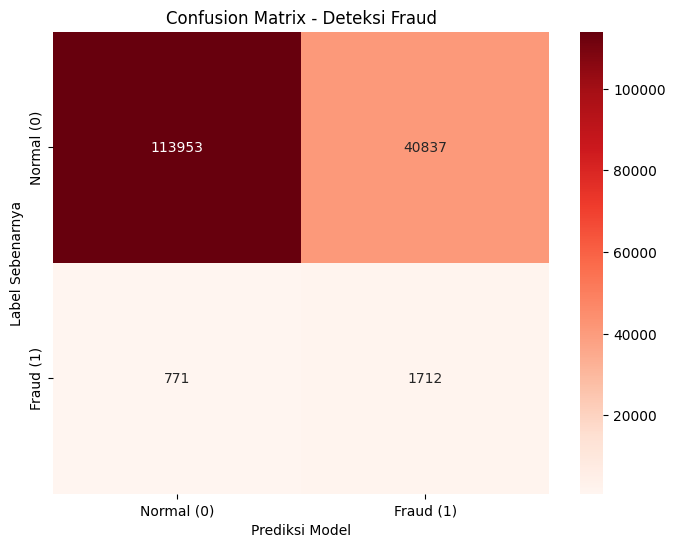

In [8]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menghitung beban (weight) untuk kelas Fraud
neg_class = sum(y_train == 0)
pos_class = sum(y_train == 1)
scale_weight = neg_class / pos_class

print(f"Rasio scale_pos_weight yang digunakan: {scale_weight:.2f}")

# 2. Inisialisasi Model XGBoost
model = xgb.XGBClassifier(
    scale_pos_weight=scale_weight,
    random_state=42,
    n_estimators=100,  # Jumlah pohon keputusan (bisa di-tuning nanti)
    max_depth=5,       # Kedalaman maksimal pohon
    learning_rate=0.1,
    n_jobs=-1          # Gunakan seluruh core CPU agar training lebih cepat
)

# 3. Proses Training
print("Memulai proses training model XGBoost... (Ini mungkin memakan waktu sekitar 1-2 menit)")
model.fit(X_train, y_train)
print("Training selesai!\n")

# 4. Evaluasi Model pada Data Uji (X_test)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Mengambil nilai probabilitas kelas 1 (Fraud)

print("=== Laporan Klasifikasi (Classification Report) ===")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}\n")

# 5. Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal (0)', 'Fraud (1)'],
            yticklabels=['Normal (0)', 'Fraud (1)'])
plt.title('Confusion Matrix - Deteksi Fraud')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.show()

## **FINE TUNNING**

Memulai Hyperparameter Tuning... (Silakan tunggu, ini bisa memakan waktu 5-10 menit)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=7, n_estimators=100, scale_pos_weight=30, subsample=0.8; total time=  13.4s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=7, n_estimators=100, scale_pos_weight=30, subsample=0.8; total time=  14.5s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=7, n_estimators=100, scale_pos_weight=30, subsample=0.8; total time=   8.9s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=100, scale_pos_weight=20, subsample=0.8; total time=   6.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=100, scale_pos_weight=20, subsample=0.8; total time=   9.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=100, scale_pos_weight=20, subsample=0.8; total time=   5.8s
[CV] END colsample_bytree=1.0, l

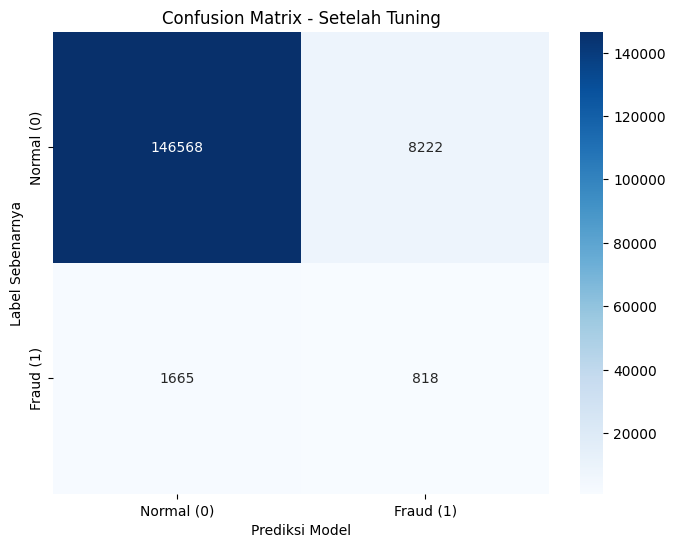

In [9]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Menentukan ruang pencarian parameter (Parameter Grid)
param_dist = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
    # Kita coba turunkan bobot agar model tidak terlalu agresif menebak Fraud
    'scale_pos_weight': [10, 20, 30, 45, 62],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 2. Inisialisasi model dasar
xgb_base = xgb.XGBClassifier(random_state=42, n_jobs=-1)

# 3. Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',  # Fokus mengoptimalkan F1-Score (Keseimbangan Precision & Recall)
    cv=3,          # 3-Fold Cross Validation
    verbose=2,
    random_state=42
)

print("Memulai Hyperparameter Tuning... (Silakan tunggu, ini bisa memakan waktu 5-10 menit)")
random_search.fit(X_train, y_train)

# 4. Menampilkan hasil terbaik
print("\n=== Parameter Terbaik Ditemukan ===")
print(random_search.best_params_)

# 5. Evaluasi menggunakan model terbaik
best_model = random_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_pred_proba_tuned = best_model.predict_proba(X_test)[:, 1]

print("\n=== Laporan Klasifikasi Setelah Tuning ===")
print(classification_report(y_test, y_pred_tuned))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_tuned):.4f}\n")

# 6. Visualisasi Confusion Matrix Baru
plt.figure(figsize=(8, 6))
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Fraud (1)'],
            yticklabels=['Normal (0)', 'Fraud (1)'])
plt.title('Confusion Matrix - Setelah Tuning')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.show()

/tmp/ipykernel_3175/3217322611.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tingkat_Kepentingan', y='Fitur', data=df_importance, palette='viridis')


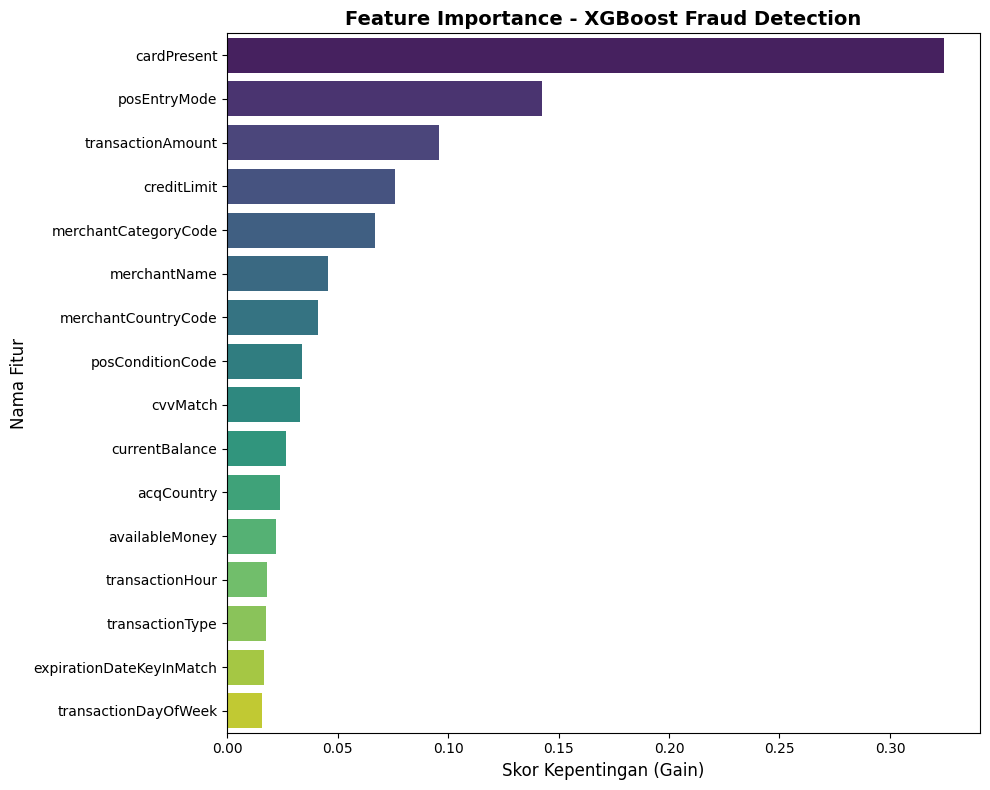

=== Top 5 Fitur Paling Berpengaruh ===


,Fitur,Tingkat_Kepentingan
11,cardPresent,0.324530
6,posEntryMode,0.142420
2,transactionAmount,0.095697
0,creditLimit,0.076029
8,merchantCategoryCode,0.066711


In [10]:
import pandas as pd

# 1. Mengambil nilai kepentingan fitur (berdasarkan 'gain' pada XGBoost)
importances = best_model.feature_importances_
fitur = X_train.columns

# 2. Menyusunnya ke dalam DataFrame agar mudah diurutkan
df_importance = pd.DataFrame({'Fitur': fitur, 'Tingkat_Kepentingan': importances})
df_importance = df_importance.sort_values(by='Tingkat_Kepentingan', ascending=False)

# 3. Visualisasi Bar Chart
plt.figure(figsize=(10, 8))
sns.barplot(x='Tingkat_Kepentingan', y='Fitur', data=df_importance, palette='viridis')
plt.title('Feature Importance - XGBoost Fraud Detection', fontsize=14, fontweight='bold')
plt.xlabel('Skor Kepentingan (Gain)', fontsize=12)
plt.ylabel('Nama Fitur', fontsize=12)
plt.tight_layout()
plt.show()

# Menampilkan top 5 fitur dalam bentuk teks
print("=== Top 5 Fitur Paling Berpengaruh ===")
display(df_importance.head(5))

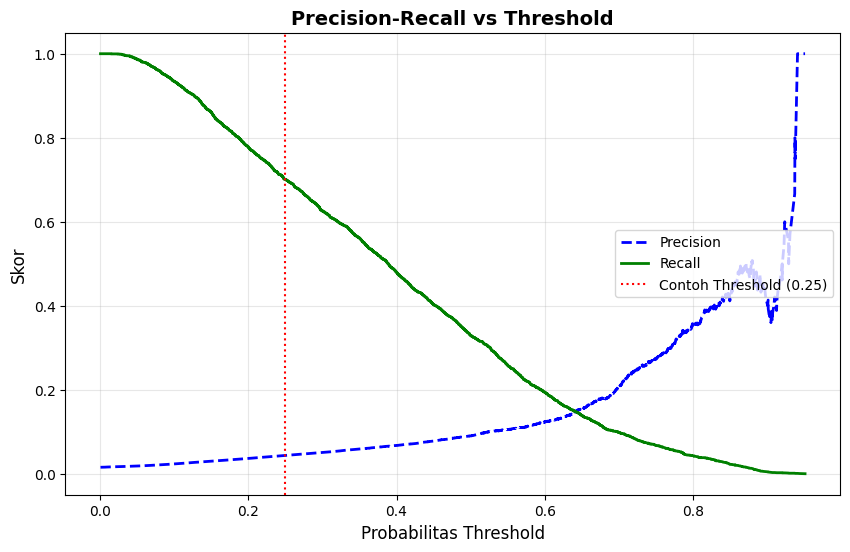

=== Evaluasi dengan Custom Threshold (0.25) ===
              precision    recall  f1-score   support

           0       0.99      0.75      0.86    154790
           1       0.04      0.70      0.08      2483

    accuracy                           0.75    157273
   macro avg       0.52      0.73      0.47    157273
weighted avg       0.98      0.75      0.85    157273

Bandingkan metrik kelas '1' (Fraud) ini dengan hasil tuning sebelumnya!


In [11]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. Menghitung nilai Precision dan Recall untuk setiap kemungkinan threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_tuned)

# 2. Visualisasi Trade-off
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
# Menandai titik pertemuan (Intersection)
plt.axvline(x=0.25, color='r', linestyle=':', label='Contoh Threshold (0.25)')

plt.xlabel("Probabilitas Threshold", fontsize=12)
plt.ylabel("Skor", fontsize=12)
plt.title("Precision-Recall vs Threshold", fontsize=14, fontweight='bold')
plt.legend(loc="center right")
plt.grid(True, alpha=0.3)
plt.show()

# 3. Menerapkan Custom Threshold (misalnya 0.25)
custom_threshold = 0.25
y_pred_custom = (y_pred_proba_tuned >= custom_threshold).astype(int)

print(f"=== Evaluasi dengan Custom Threshold ({custom_threshold}) ===")
print(classification_report(y_test, y_pred_custom))

# Menampilkan sedikit perbandingan
print("Bandingkan metrik kelas '1' (Fraud) ini dengan hasil tuning sebelumnya!")


coba lagi

In [12]:
!pip install imbalanced-learn

=== 1. Menerapkan SMOTE ===
Jumlah data sebelum SMOTE: (629090, 16)
isFraud
0    619156
1      9934
Name: count, dtype: int64

Jumlah data setelah SMOTE:
isFraud
0    619156
1     61915
Name: count, dtype: int64

=== 2. Melatih Ulang Model XGBoost ===
Training selesai!

=== 3. Evaluasi Model SMOTE pada Data Uji (Asli) ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    154790
           1       0.20      0.04      0.07      2483

    accuracy                           0.98    157273
   macro avg       0.59      0.52      0.53    157273
weighted avg       0.97      0.98      0.98    157273

ROC-AUC Score: 0.7457



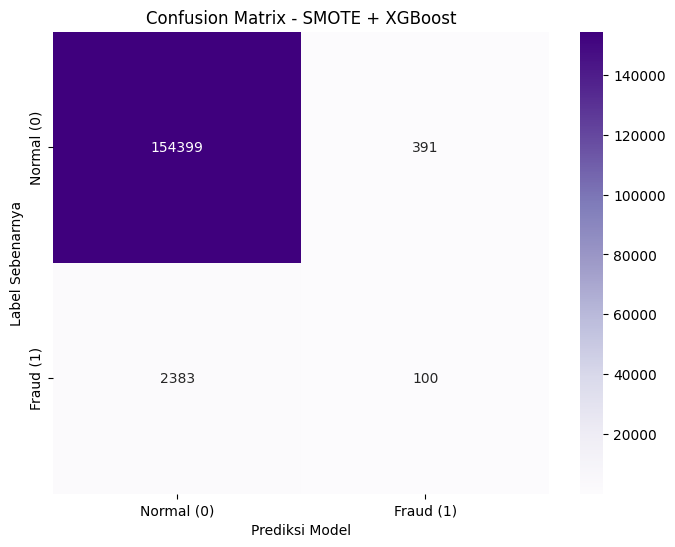

In [13]:
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("=== 1. Menerapkan SMOTE ===")
print("Jumlah data sebelum SMOTE:", X_train.shape)
print(y_train.value_counts())

# Tingkatkan jumlah kelas minoritas (Fraud) menjadi 10% dari jumlah kelas mayoritas
# Tidak perlu 50:50 karena bisa menyebabkan overfitting pada noise
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nJumlah data setelah SMOTE:")
print(y_train_smote.value_counts())

print("\n=== 2. Melatih Ulang Model XGBoost ===")
# Mematikan scale_pos_weight karena kelas minoritas sudah kita perbanyak
model_smote = xgb.XGBClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    n_jobs=-1
)

model_smote.fit(X_train_smote, y_train_smote)
print("Training selesai!\n")

print("=== 3. Evaluasi Model SMOTE pada Data Uji (Asli) ===")
y_pred_smote = model_smote.predict(X_test)
y_pred_proba_smote = model_smote.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_smote))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_smote):.4f}\n")

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
cm_smote = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Normal (0)', 'Fraud (1)'],
            yticklabels=['Normal (0)', 'Fraud (1)'])
plt.title('Confusion Matrix - SMOTE + XGBoost')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.show()

In [15]:
import pandas as pd
import numpy as np

print("=== 1. Memuat Ulang & Persiapan Data ===")
df_raw = pd.read_json('/content/drive/MyDrive/ColabNotebooks/ml/fraud/transactions.txt', lines=True)
df_raw.replace('', np.nan, inplace=True)
df_raw['transactionDateTime'] = pd.to_datetime(df_raw['transactionDateTime'])

df_raw = df_raw.sort_values(by=['accountNumber', 'transactionDateTime'])

print("=== 2. Membangun Velocity Features (Pola Perilaku) ===")
df_raw = df_raw.set_index('transactionDateTime')

df_raw['trx_count_24h'] = df_raw.groupby('accountNumber')['transactionAmount'].rolling('1D').count().reset_index(level=0, drop=True)
df_raw['trx_sum_24h'] = df_raw.groupby('accountNumber')['transactionAmount'].rolling('1D').sum().reset_index(level=0, drop=True)
df_raw['trx_sum_7d'] = df_raw.groupby('accountNumber')['transactionAmount'].rolling('7D').sum().reset_index(level=0, drop=True)

df_raw = df_raw.reset_index()

df_raw['avg_daily_spend_7d'] = df_raw['trx_sum_7d'] / 7

df_raw['amount_vs_7d_avg'] = df_raw['transactionAmount'] / df_raw['avg_daily_spend_7d'].replace(0, 1)

print("Fitur agregasi perilaku berhasil dibuat!")
display(df_raw[['accountNumber', 'transactionDateTime', 'transactionAmount', 'trx_count_24h', 'trx_sum_24h', 'amount_vs_7d_avg']].head(10))

=== 1. Memuat Ulang & Persiapan Data ===


/tmp/ipykernel_3175/3803976089.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_raw.replace('', np.nan, inplace=True)


=== 2. Membangun Velocity Features (Pola Perilaku) ===
Fitur agregasi perilaku berhasil dibuat!


,accountNumber,transactionDateTime,transactionAmount,trx_count_24h,trx_sum_24h,amount_vs_7d_avg
0,100088067,2016-01-12 00:59:52,205.13,1.0,205.13,7.000000
1,100088067,2016-01-12 19:49:41,46.43,2.0,251.56,1.291978
2,100088067,2016-01-17 15:41:46,378.67,1.0,378.67,4.205909
3,100088067,2016-02-02 19:57:18,66.07,1.0,66.07,7.000000
4,100088067,2016-02-03 04:48:54,141.60,2.0,207.67,4.772957
5,100088067,2016-02-08 06:09:12,259.44,1.0,259.44,3.887906
6,100088067,2016-02-09 18:36:53,32.50,1.0,32.50,0.455355
7,100088067,2016-02-09 23:44:13,23.06,2.0,55.56,0.353526
8,100088067,2016-02-13 20:17:41,56.05,1.0,56.05,1.057405
9,100088067,2016-02-21 01:14:56,71.35,1.0,71.35,7.000000


In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ekstrak komponen waktu
df_raw['transactionHour'] = df_raw['transactionDateTime'].dt.hour
df_raw['transactionDayOfWeek'] = df_raw['transactionDateTime'].dt.dayofweek

# Fitur kecocokan CVV
df_raw['cvvMatch'] = (df_raw['cardCVV'] == df_raw['enteredCVV']).astype(int)

cols_with_nan = ['acqCountry', 'merchantCountryCode', 'posEntryMode', 'posConditionCode', 'transactionType']
for col in cols_with_nan:
    df_raw[col] = df_raw[col].fillna('UNKNOWN')

cols_to_drop = ['transactionDateTime', 'currentExpDate', 'accountOpenDate',
                'dateOfLastAddressChange', 'cardLast4Digits', 'cardCVV', 'enteredCVV',
                'echoBuffer', 'merchantCity', 'merchantState', 'merchantZip',
                'posOnPremises', 'recurringAuthInd', 'customerId', 'accountNumber']
df_final = df_raw.drop(columns=cols_to_drop, errors='ignore')

bool_cols = df_final.select_dtypes(include=['bool']).columns
for col in bool_cols:
    df_final[col] = df_final[col].astype(int)

le = LabelEncoder()
obj_cols = df_final.select_dtypes(include=['object']).columns
for col in obj_cols:
    df_final[col] = le.fit_transform(df_final[col].astype(str))

X = df_final.drop(columns=['isFraud'])
y = df_final['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dimensi X_train baru: {X_train.shape}")

# 4. Training XGBoost (menggunakan parameter terbaik sebelumnya)
print("\nMelatih XGBoost dengan Velocity Features...")
model_vel = xgb.XGBClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=20,  # Mempertahankan penalti moderat untuk kelas minoritas
    subsample=0.8,
    colsample_bytree=1.0,
    n_jobs=-1
)

model_vel.fit(X_train, y_train)
print("Training selesai!\n")

y_pred_vel = model_vel.predict(X_test)
y_pred_proba_vel = model_vel.predict_proba(X_test)[:, 1]

print("=== Laporan Klasifikasi (Dengan Velocity Features) ===")
print(classification_report(y_test, y_pred_vel))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_vel):.4f}\n")

importances_vel = model_vel.feature_importances_
df_imp_vel = pd.DataFrame({'Fitur': X_train.columns, 'Tingkat_Kepentingan': importances_vel})
print("=== Top 10 Fitur Paling Berpengaruh ===")
display(df_imp_vel.sort_values(by='Tingkat_Kepentingan', ascending=False).head(10))

Dimensi X_train baru: (629090, 21)

Melatih XGBoost dengan Velocity Features...
Training selesai!

=== Laporan Klasifikasi (Dengan Velocity Features) ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97    154790
           1       0.10      0.36      0.16      2483

    accuracy                           0.94    157273
   macro avg       0.55      0.65      0.57    157273
weighted avg       0.98      0.94      0.96    157273

ROC-AUC Score: 0.8194

=== Top 10 Fitur Paling Berpengaruh ===


,Fitur,Tingkat_Kepentingan
11,cardPresent,0.291404
6,posEntryMode,0.123749
2,transactionAmount,0.105244
0,creditLimit,0.062716
8,merchantCategoryCode,0.056413
3,merchantName,0.042423
5,merchantCountryCode,0.037244
15,trx_sum_7d,0.036125
13,trx_count_24h,0.033413
20,cvvMatch,0.025499


In [17]:
import joblib

save_path = '/content/drive/MyDrive/ColabNotebooks/ml/fraud/'

model_vel.save_model(f'{save_path}xgboost_fraud_model.json')

joblib.dump(le, f'{save_path}label_encoder.joblib')

# Backend harus menyusun payload JSON sesuai urutan kolom ini sebelum diprediksi
expected_features = X_train.columns.tolist()
joblib.dump(expected_features, f'{save_path}expected_features.joblib')

print("=== Artifact berhasil diekspor! ===")
print("1. xgboost_fraud_model.json")
print("2. label_encoder.joblib")
print("3. expected_features.joblib")

=== Artifact berhasil diekspor! ===
1. xgboost_fraud_model.json
2. label_encoder.joblib
3. expected_features.joblib
